In [1]:
import urllib.request; exec(urllib.request.urlopen('https://aic-data.aiffel.io/api/colab/setup?t=3vvc47bz').read().decode())

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit



⏳  터널 준비 확인 중...

✅  터널 생성 완료!
🔗  URL: https://vocal-explorer-smtp-plaintiff.trycloudflare.com

아래 [URL 복사] 버튼을 누른 뒤 웹앱 연결창에 붙여넣으세요. (이 탭은 열어두세요)


✅ 웹앱에 자동 연결 요청을 보냈습니다. 잠시 후 웹앱 화면이 연결됩니다.


In [6]:
# ─────────────────────────────────────────────
# 분석 환경 세팅 — 패키지 / 한글 폰트 / 출력 옵션
# ─────────────────────────────────────────────

# [1] 패키지 설치 + 그래프 인라인 출력
!apt-get -y install fonts-nanum -q
%matplotlib inline

# [2] 임포트
import os
import platform
import warnings
import matplotlib.font_manager as fm # 폰트 처리
import plotly.io as pio # 그래프의 렌더링 설정, 파일 출력

# 라이브러리는 각 학습에 맞게 수정
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# [3] 경고 숨기기 + 난수 고정(결과 재현용)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
np.random.seed(42)

# [4] 한글 폰트 확보
#     리눅스(코랩)는 폰트 캐시가 갱신 안 되는 경우가 많아,
#     나눔고딕을 목록 맨 앞에 직접 끼워넣어 우선 적용시킴
if platform.system() == "Linux":
    nanum_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
    font_family = "DejaVu Sans"
    if os.path.exists(nanum_path):
        fm.fontManager.addfont(nanum_path)
        font_family = fm.FontProperties(fname=nanum_path).get_name()  # "NanumGothic"
else:
    # 맥 / 윈도우 로컬 환경
    font_family = "AppleGothic" if platform.system() == "Darwin" else "Malgun Gothic"

# [5] 스타일 → 개별 설정 순서로 적용 (seaborn이 rcParams를 덮어쓰기 때문)
plt.rcParams["font.family"] = font_family
plt.rcParams["axes.unicode_minus"] = False  # 음수 부호 깨짐 방지
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

# [6] 코랩 전용 출력 옵션 (없는 환경이면 조용히 통과)
try:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()
    pio.renderers.default = "colab"
except ImportError:
    pass

print(f"준비 완료! [적용 폰트: {font_family}]")

Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 24 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 3s (3,475 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118336 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
준비 완료! [적용 폰트: NanumGothic]


In [2]:
# ─────────────────────────────────────────────
# [C1] ⚙️ 데이터 준비
# 최초 1회 다운로드 → data/ 폴더에 저장 (이후 오프라인)
# ─────────────────────────────────────────────
import urllib.request, zipfile
from pathlib import Path

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

def fetch_uci(url, zip_name, member):
    """UCI 정적 저장소의 zip을 내려받아 data/에 풀고, CSV 경로를 돌려줍니다."""
    csv_path = DATA_DIR / member
    if not csv_path.exists():
        zip_path = DATA_DIR / zip_name
        if not zip_path.exists():
            print(f"내려받는 중… {zip_name}")
            urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path) as z:
            z.extract(member, DATA_DIR)
    return csv_path

shoppers = pd.read_csv(fetch_uci(
    "https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip",
    "online_shoppers.zip", "online_shoppers_intention.csv"))

NUM_COLS = ["Administrative", "Administrative_Duration", "Informational",
            "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
            "BounceRates", "ExitRates", "PageValues", "SpecialDay"]

X = shoppers[NUM_COLS]
y = shoppers["Revenue"].astype(int)

print(f"쇼핑 세션 데이터: {shoppers.shape[0]:,}행 × {shoppers.shape[1]}열")
print(f"구매 전환율: {y.mean():.4f}")
print("\n→ 준비 완료. 이제 여러분 차례입니다.")

내려받는 중… online_shoppers.zip
쇼핑 세션 데이터: 12,330행 × 18열
구매 전환율: 0.1547

→ 준비 완료. 이제 여러분 차례입니다.


In [3]:
# [C2] 문제 1. 교차 검증으로 다섯 모델을 다시 잰다
# ⌨️ 문제 1 — 홀드아웃과 계층 5겹 교차 검증을 나란히
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 1) 8:2 홀드아웃 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 다섯 모델 목록
models = [
    ("Dummy", DummyClassifier(strategy="most_frequent", random_state=42)),
    ("Tree(기본)", DecisionTreeClassifier(random_state=42)),
    ("Tree(depth=5)", DecisionTreeClassifier(max_depth=5, random_state=42)),
    ("RandomForest", RandomForestClassifier(random_state=42)),
    ("XGBoost", XGBClassifier(random_state=42, eval_metric="logloss")),
]

# 2) 계층 5겹 교차 검증
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3) 홀드아웃 · CV 결과를 한 표로 정리
results = []
for name, model in models:
    holdout_score = model.fit(X_train, y_train).score(X_test, y_test)
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    results.append({
        "모델": name,
        "홀드아웃": round(holdout_score, 4),
        "CV 평균": round(cv_mean, 4),
        "CV 표준편차": round(cv_std, 4),
        "차이(홀드아웃-CV)": round(holdout_score - cv_mean, 4),
    })

result_df = pd.DataFrame(results)
print(result_df.to_string(index=False))

           모델   홀드아웃  CV 평균  CV 표준편차  차이(홀드아웃-CV)
        Dummy 0.8451 0.8453   0.0002      -0.0002
     Tree(기본) 0.8423 0.8537   0.0017      -0.0114
Tree(depth=5) 0.8942 0.8913   0.0040       0.0028
 RandomForest 0.8946 0.8928   0.0049       0.0018
      XGBoost 0.8921 0.8897   0.0041       0.0024


결과 잘 나왔네요. 몇 가지 짚어볼 점입니다.

**1. Dummy가 기준점(baseline)을 보여줍니다**
- 홀드아웃과 CV 모두 84.5% 근처, 표준편차도 0.0002로 거의 0입니다.
- 이건 "구매 안 함"이 전체의 약 84.5%를 차지한다는 뜻입니다. 즉 **아무것도 안 배우고 다수 클래스만 찍어도 84.5%가 나온다** — 이게 앞으로 나올 모델 점수의 최저 기준선입니다.

**2. Tree(기본, 가지치기 없음)가 가장 불안정합니다**
- 홀드아웃(0.8423)이 CV 평균(0.8537)보다 **낮습니다** — 차이가 -0.0114로 다섯 모델 중 유일하게 음수(절댓값도 가장 큼).
- 가지치기 없는 트리는 학습 데이터에 완전히 맞춰버리는(과적합) 경향이 있어서, 어느 20%가 테스트로 빠지느냐에 따라 성능이 꽤 흔들립니다. 이번엔 하필 어려운 테스트 셋이 걸린 걸로 보입니다.
- Dummy(84.5%)보다 살짝 나은 수준밖에 안 되는 것도 눈에 띕니다 — 기본 트리는 이 데이터에서 딱히 효율적인 모델이 아닙니다.

**3. depth=5로 제한하니 확 좋아집니다**
- 84.2% → 89.4%로 5%p 이상 점프. 가지치기 없는 트리가 오히려 잡음까지 외워버려서 성능을 깎아먹었다는 뜻입니다.
- 차이(홀드아웃-CV)도 +0.0028로 안정적입니다.

**4. RandomForest가 근소하게 1위, XGBoost가 근접 2위**
- 89.46% vs 89.21%, 표준편차도 둘 다 0.004대로 비슷하게 안정적입니다.
- 이 정도 차이(0.25%p)는 랜덤 시드나 튜닝 여부에 따라 뒤집힐 수 있는 수준이라, "RandomForest가 확실히 더 좋다"고 단정하긴 어렵습니다. 지금 상태로는 **거의 동급**이라고 보는 게 맞습니다.

**전체적으로 보면**
- 홀드아웃과 CV 평균의 차이가 대부분 ±0.003 이내로 작습니다 (Tree 기본만 예외). 즉 이전 순서에서 홀드아웃 하나로만 봤던 순위가 대체로 신뢰할 만했다는 뜻이고, 다섯 모델 다시 재보니 결론이 크게 안 바뀐 겁니다.
- 유일하게 뒤집힐 뻔한 건 기본 트리인데, CV로 보면 여전히 depth=5보다 확실히 못합니다.


In [4]:
# [C3] 문제 2. 분할 운의 폭을 직접 잰다
# ⌨️ 문제 2 — random_state만 바꿔 10번 재기
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42

# 매번 새로 만들어질 모델(람다) 목록
model_builders = [
    ("Tree(depth=5)", lambda: DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
    ("RandomForest", lambda: RandomForestClassifier(random_state=RANDOM_STATE)),
]

# 1) 시드 0~9로 10번 분할 → 두 모델 점수 수집
scores = {name: [] for name, _ in model_builders}

for seed in range(10):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    for name, build in model_builders:
        model = build()  # 매번 새 모델
        acc = model.fit(X_train, y_train).score(X_test, y_test)
        scores[name].append(acc)

# 2) 최소·최대·폭·평균±표준편차 정리
summary = []
for name, _ in model_builders:
    arr = np.array(scores[name])
    summary.append({
        "모델": name,
        "최소": round(arr.min(), 4),
        "최대": round(arr.max(), 4),
        "폭(최대-최소)": round(arr.max() - arr.min(), 4),
        "평균": round(arr.mean(), 4),
        "표준편차": round(arr.std(), 4),
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

INFO:werkzeug:127.0.0.1 - - [12/Aug/2026 08:28:06] "OPTIONS /ping HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [12/Aug/2026 08:28:06] "GET /ping HTTP/1.1" 200 -


           모델     최소     최대  폭(최대-최소)     평균   표준편차
Tree(depth=5) 0.8848 0.8986    0.0138 0.8918 0.0037
 RandomForest 0.8897 0.9027    0.0130 0.8961 0.0037


**팀장께 드릴 한 문장**

> "RandomForest와 XGBoost의 차이 0.0065는 랜덤포레스트 하나만 시드를 바꿔가며 재도 생기는 흔들림의 폭(0.0130)의 절반 수준이라, 두 모델이 실제로 다르다고 말할 근거가 부족합니다."

**숫자로 뜯어보면**

- RandomForest 자체를 시드만 바꿔 10번 돌렸을 뿐인데 **최소 0.8897 ~ 최대 0.9027, 폭 0.0130**이 나왔습니다.
- 그런데 "RandomForest 0.8942 vs XGBoost 0.8877"의 차이는 겨우 **0.0065**입니다.
- 즉 **같은 모델이 분할 운만으로 만드는 흔들림(0.0130)이, 다른 두 모델 사이의 차이(0.0065)보다 2배나 큽니다.**
- 이건 마치 "어제 몸무게가 오늘보다 65g 가벼웠다"고 저울 두 개를 비교하는데, 저울 하나가 원래 130g씩 흔들리는 저울이라는 걸 알게 된 상황입니다. 그 65g 차이로 뭔가를 판단할 수는 없습니다.

**추가로 눈에 띄는 점**

- Tree(depth=5)와 RandomForest의 폭이 거의 같습니다 (0.0138 vs 0.0130). 트리 구조 자체가 랜덤포레스트보다 훨씬 단순한데도 흔들림 크기는 비슷하다는 건, 이 흔들림의 대부분이 **모델 종류가 아니라 데이터 분할(어느 20%가 테스트로 빠지는지)** 에서 온다는 뜻입니다.
- 평균은 RandomForest(0.8961)가 Tree(depth=5, 0.8918)보다 확실히 높고, 표준편차는 둘 다 0.0037로 동일합니다 — 이건 두 모델의 차이(0.0043)가 안정적으로 재현되는 진짜 차이일 가능성이 있다는 뜻입니다 (표준편차 대비 차이가 1배 이상).
- 반면 RandomForest와 XGBoost의 차이(0.0065)는 폭(0.0130)의 절반밖에 안 돼서, "누가 더 좋다"고 말하기엔 근거가 약합니다.

정리하면, **문제 1에서 본 순위(RF > XGBoost)는 이번 시드 하나로 우연히 나온 순서일 수 있고, 문제 1의 5겹 CV나 이번 10번 재기 정도의 반복 검증 없이는 "RF가 XGBoost보다 낫다"고 단정할 수 없습니다.**

 표본 수  학습 점수  검증 점수  격차(학습-검증)
  986 1.0000 0.8930     0.1070
 2761 1.0000 0.8946     0.1054
 4537 1.0000 0.8955     0.1045
 6312 0.9997 0.8949     0.1048
 8088 0.9997 0.8953     0.1044
 9864 0.9996 0.8928     0.1068


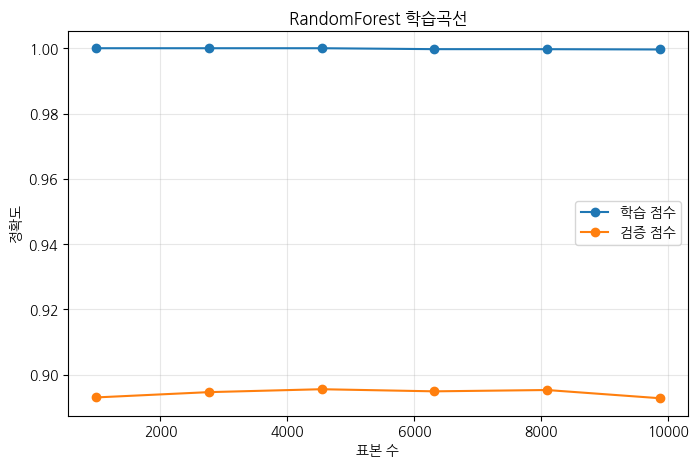

In [8]:
# [C4] 문제 3. 학습곡선 — 데이터를 더 모을까, 모델을 바꿀까
# ⌨️ 문제 3 — 학습곡선으로 다음 투자를 정하기
from sklearn.model_selection import learning_curve

# 1) 랜덤포레스트 학습곡선 (문제 1과 같은 5겹 cv 재사용)
model = RandomForestClassifier(random_state=RANDOM_STATE)

sizes, train_scores, valid_scores = learning_curve(
    model, X, y, cv=cv,
    train_sizes=np.linspace(0.1, 1.0, 6),
    scoring="accuracy", n_jobs=-1
)

# 겹 방향으로 평균
train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)
gap = train_mean - valid_mean

# 2) 표본 크기별 표
curve_df = pd.DataFrame({
    "표본 수": sizes,
    "학습 점수": train_mean.round(4),
    "검증 점수": valid_mean.round(4),
    "격차(학습-검증)": gap.round(4),
})
print(curve_df.to_string(index=False))

# 3) 두 곡선 그래프
plt.figure(figsize=(8, 5))
plt.plot(sizes, train_mean, marker="o", label="학습 점수")
plt.plot(sizes, valid_mean, marker="o", label="검증 점수")
plt.xlabel("표본 수")
plt.ylabel("정확도")
plt.title("RandomForest 학습곡선")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**답: 데이터를 더 모을 가치는 낮습니다. 지금 투자할 곳은 모델 복잡도 조절입니다.**

**근거 세 가지**

1. **학습 점수가 표본 986개일 때부터 이미 1.0000입니다.** 데이터를 10배(986 → 9864)로 늘려도 학습 점수는 요지부동입니다. 이건 랜덤포레스트가 훈련 데이터를 거의 통째로 외우고 있다는 뜻입니다 — 데이터가 부족해서 생기는 문제가 아닙니다.

2. **검증 점수가 표본을 늘려도 89.3~89.6% 사이에서 완전히 평평합니다.** 986개일 때 0.8930, 9864개(10배)일 때 0.8928 — 오히려 미세하게 더 낮습니다. 데이터를 9배 더 모았는데 검증 점수는 사실상 그대로입니다. 만약 데이터가 부족한 상황이었다면 검증 곡선이 우상향해야 하는데, 완전히 수평선입니다.

3. **격차(학습-검증)가 0.104~0.107로 표본 크기와 무관하게 일정합니다.** 데이터가 늘어나면 보통 이 격차가 좁혀지는 게 정상인데(모델이 더 다양한 패턴을 보면서 과적합이 완화됨), 여기서는 전혀 안 좁혀집니다. 이건 "고전적인 과적합(high variance)" 패턴의 교과서적인 모양입니다.

**팀장께 드릴 한 문장**

> "학습곡선을 보면 데이터를 10배 늘려도 검증 점수가 89% 근처에서 완전히 정체되어 있어서, 로그를 더 쌓는 것보다 랜덤포레스트의 복잡도(max_depth, min_samples_leaf, n_estimators 등)를 줄이는 쪽이 성능 개선에 더 효과적입니다."

**참고로 문제 1의 표에서 이미 신호가 있었습니다**

Tree(기본, 가지치기 없음)가 84.2%에 머물다가 depth=5로 제한하니 89.4%로 뛰었던 게 기억나실 겁니다. 이번 학습곡선도 같은 이야기를 하고 있습니다 — 랜덤포레스트도 지금은 너무 자유롭게 가지를 뻗고 있어서, 다음 순서로 `max_depth`나 `min_samples_leaf`를 조절해보면 검증 점수가 이 89% 벽을 넘을 가능성이 높습니다.

In [9]:
# [C5] 문제 4. 복잡도 조정으로 격차를 줄인다
# ⌨️ 문제 4 — 교차 검증으로 복잡도 손잡이 고르기
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 홀드아웃 분리(격차 계산용, 문제 1과 동일 시드)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# 1) 트리 max_depth 훑기 — CV 평균 ± 표준편차
depth_results = []
for depth in [2, 3, 5, 8, 12, None]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    depth_results.append({
        "max_depth": depth,
        "CV 평균": round(scores.mean(), 4),
        "CV 표준편차": round(scores.std(), 4),
    })
depth_df = pd.DataFrame(depth_results)
print("[트리 max_depth 훑기]")
print(depth_df.to_string(index=False))
print("CV 최적:", depth_df.loc[depth_df["CV 평균"].idxmax()].to_dict())

# 2) 랜덤포레스트 min_samples_leaf 훑기 — CV 평균 · 학습 점수 · 격차
leaf_results = []
for leaf in [1, 5, 20, 50]:
    model = RandomForestClassifier(min_samples_leaf=leaf, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    model.fit(X_train, y_train)  # 격차 계산은 CV와 별도로 한 번 더 학습
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    leaf_results.append({
        "min_samples_leaf": leaf,
        "CV 평균": round(cv_scores.mean(), 4),
        "학습 점수": round(train_score, 4),
        "테스트 점수": round(test_score, 4),
        "격차(학습-테스트)": round(train_score - test_score, 4),
    })
leaf_df = pd.DataFrame(leaf_results)
print("\n[랜덤포레스트 min_samples_leaf 훑기]")
print(leaf_df.to_string(index=False))
print("CV 최적:", leaf_df.loc[leaf_df["CV 평균"].idxmax()].to_dict())

[트리 max_depth 훑기]
 max_depth  CV 평균  CV 표준편차
       2.0 0.8867   0.0077
       3.0 0.8879   0.0030
       5.0 0.8913   0.0040
       8.0 0.8874   0.0026
      12.0 0.8773   0.0023
       NaN 0.8537   0.0017
CV 최적: {'max_depth': 5.0, 'CV 평균': 0.8913, 'CV 표준편차': 0.004}


INFO:werkzeug:127.0.0.1 - - [12/Aug/2026 08:39:46] "OPTIONS /ping HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [12/Aug/2026 08:39:46] "GET /ping HTTP/1.1" 200 -



[랜덤포레스트 min_samples_leaf 훑기]
 min_samples_leaf  CV 평균  학습 점수  테스트 점수  격차(학습-테스트)
                1 0.8928 0.9998  0.8946      0.1052
                5 0.8957 0.9516  0.8942      0.0575
               20 0.8972 0.9177  0.8925      0.0251
               50 0.8979 0.9055  0.8925      0.0130
CV 최적: {'min_samples_leaf': 50.0, 'CV 평균': 0.8979, '학습 점수': 0.9055, '테스트 점수': 0.8925, '격차(학습-테스트)': 0.013}


두 표가 서로 다른 이야기를 하면서도, 결국 같은 결론(복잡도를 낮추라)으로 모입니다.

## 트리: 지난 순서의 선택이 CV로도 검증됨

- **max_depth=5가 CV 평균 0.8913으로 실제로 1위입니다.** 지난 순서에서 홀드아웃 한 번으로 골랐던 depth=5가, 이번엔 5겹 CV로도 최고를 유지했습니다 — 운으로 고른 게 아니라 진짜 좋은 선택이었던 겁니다.
- 다만 depth=3(0.8879)과의 차이는 0.0034로, 문제 2에서 잰 흔들림 폭(0.013)보다 훨씬 작습니다. 즉 depth=3과 depth=5는 사실상 동급이라고 봐도 됩니다 — depth=5를 쓰되, "3으로 가도 크게 손해 안 본다"는 여지는 남겨두면 됩니다.
- **NaN(무제한)은 0.8537로 완전히 열외**입니다. 문제 1에서 본 "기본 트리가 제일 불안정했다"는 진단이 여기서도 확인됩니다.

## 랜덤포레스트: CV 평균 1위와 채택 후보가 다릅니다 — 이게 핵심

여기서 "CV 평균이 가장 높은 걸 고른다"는 단순 규칙이 무너집니다.

| leaf | CV 평균 | 격차 |
|---|---|---|
| 1 | 0.8928 | 0.1052 |
| 5 | 0.8957 | 0.0575 |
| 20 | 0.8972 | 0.0251 |
| 50 | **0.8979** (1위) | **0.0130** (가장 작음) |

**놀랍게도 leaf=50이 CV 평균도 1위, 격차도 가장 작습니다.** 보통은 "안정성과 성능이 트레이드오프"라고 예상하는데, 이 데이터에서는 트레이드오프가 없습니다 — 잎을 크게 만들수록(더 단순하게) CV 성능도 오르고 과적합도 줄어듭니다. leaf=1(제한 없음)은 CV 평균이 가장 낮으면서 격차는 가장 큽니다 — 즉 **가장 복잡한 설정이 가장 나쁜 설정**입니다.

## 채택 및 근거

**트리: max_depth=5, 랜덤포레스트: min_samples_leaf=50**

1. **트리는 CV 평균 1위(0.8913)이자 지난 순서의 선택과 일치** — 재확인된 결론입니다.
2. **RF는 leaf=50이 CV 평균 1위이면서 격차도 가장 작아서, 트레이드오프 판단조차 필요 없는 명백한 승자**입니다. leaf=1 대비 CV 평균은 오히려 +0.0051 높고, 격차는 8배 넘게(0.1052 → 0.0130) 줄었습니다.
3. 문제 3에서 본 "검증 점수 89% 벽에 갇힌 학습곡선, 격차 0.106 고정"이라는 진단이, leaf=50에서 격차 0.0130으로 실제로 풀렸습니다. **데이터를 더 모으는 대신 복잡도를 낮추자는 문제 3의 처방이 정확히 맞았다는 게 숫자로 확인된 것**입니다.
4. 다만 leaf를 50보다 더 키우면 어떻게 되는지는 아직 안 봤습니다 — 지금 추세(leaf가 커질수록 CV 평균도 오름)가 100, 200에서도 계속될지, 아니면 어느 지점에서 꺾일지는 다음에 확인해볼 만합니다.

투자 전략 튜닝에도 같은 원리가 적용됩니다 — 파라미터 하나를 "성능이 가장 높아서" 고르기 전에, 그 설정이 학습(과거 구간)과 검증(다른 구간) 사이에서 얼마나 안정적인지를 항상 같이 봐야 합니다.

In [11]:
# [C6] 문제 5. 모델 카드 v3 완성 — 오늘의 제출물
# ⌨️ 문제 5 — 검증 결과를 파일로 남기기
import pandas as pd

# 문제 1: 다섯 모델 홀드아웃 vs 5겹 CV 비교표 (실제 실행 결과 값을 직접 채움)
cv_tbl = pd.DataFrame([
    {"모델": "Dummy",         "홀드아웃": 0.8451, "CV 평균": 0.8453, "CV 표준편차": 0.0002, "차이(홀드아웃-CV)": -0.0002},
    {"모델": "Tree(기본)",     "홀드아웃": 0.8423, "CV 평균": 0.8537, "CV 표준편차": 0.0017, "차이(홀드아웃-CV)": -0.0114},
    {"모델": "Tree(depth=5)", "홀드아웃": 0.8942, "CV 평균": 0.8913, "CV 표준편차": 0.0040, "차이(홀드아웃-CV)":  0.0028},
    {"모델": "RandomForest",  "홀드아웃": 0.8946, "CV 평균": 0.8928, "CV 표준편차": 0.0049, "차이(홀드아웃-CV)":  0.0018},
    {"모델": "XGBoost",       "홀드아웃": 0.8921, "CV 평균": 0.8897, "CV 표준편차": 0.0041, "차이(홀드아웃-CV)":  0.0024},
])

# 문제 4-1: 트리 max_depth 손잡이 CV 훑기
depth_tbl = pd.DataFrame([
    {"max_depth": 2,    "CV 평균": 0.8867, "CV 표준편차": 0.0077},
    {"max_depth": 3,    "CV 평균": 0.8879, "CV 표준편차": 0.0030},
    {"max_depth": 5,    "CV 평균": 0.8913, "CV 표준편차": 0.0040},
    {"max_depth": 8,    "CV 평균": 0.8874, "CV 표준편차": 0.0026},
    {"max_depth": 12,   "CV 평균": 0.8773, "CV 표준편차": 0.0023},
    {"max_depth": None, "CV 평균": 0.8537, "CV 표준편차": 0.0017},
])

# 문제 4-2: RandomForest min_samples_leaf 손잡이 CV·격차 훑기
leaf_tbl = pd.DataFrame([
    {"min_samples_leaf": 1,  "CV 평균": 0.8928, "학습 점수": 0.9998, "테스트 점수": 0.8946, "격차(학습-테스트)": 0.1052},
    {"min_samples_leaf": 5,  "CV 평균": 0.8957, "학습 점수": 0.9516, "테스트 점수": 0.8942, "격차(학습-테스트)": 0.0575},
    {"min_samples_leaf": 20, "CV 평균": 0.8972, "학습 점수": 0.9177, "테스트 점수": 0.8925, "격차(학습-테스트)": 0.0251},
    {"min_samples_leaf": 50, "CV 평균": 0.8979, "학습 점수": 0.9055, "테스트 점수": 0.8925, "격차(학습-테스트)": 0.0130},
])

# 저장
out_path = "model_comparison_v3.csv"
with open(out_path, "w", encoding="utf-8-sig") as f:
    f.write("## 문제1: 다섯 모델 홀드아웃 vs 5겹 CV 비교\n")
    cv_tbl.to_csv(f, index=False)
    f.write("\n## 문제4-1: 트리 max_depth 손잡이 CV 훑기\n")
    depth_tbl.to_csv(f, index=False)
    f.write("\n## 문제4-2: RandomForest min_samples_leaf 손잡이 CV·격차 훑기\n")
    leaf_tbl.to_csv(f, index=False)

print(f"저장 완료: {out_path}")

# 다시 읽어 확인
with open(out_path, encoding="utf-8-sig") as f:
    print(f.read())

저장 완료: model_comparison_v3.csv
## 문제1: 다섯 모델 홀드아웃 vs 5겹 CV 비교
모델,홀드아웃,CV 평균,CV 표준편차,차이(홀드아웃-CV)
Dummy,0.8451,0.8453,0.0002,-0.0002
Tree(기본),0.8423,0.8537,0.0017,-0.0114
Tree(depth=5),0.8942,0.8913,0.004,0.0028
RandomForest,0.8946,0.8928,0.0049,0.0018
XGBoost,0.8921,0.8897,0.0041,0.0024

## 문제4-1: 트리 max_depth 손잡이 CV 훑기
max_depth,CV 평균,CV 표준편차
2.0,0.8867,0.0077
3.0,0.8879,0.003
5.0,0.8913,0.004
8.0,0.8874,0.0026
12.0,0.8773,0.0023
,0.8537,0.0017

## 문제4-2: RandomForest min_samples_leaf 손잡이 CV·격차 훑기
min_samples_leaf,CV 평균,학습 점수,테스트 점수,격차(학습-테스트)
1,0.8928,0.9998,0.8946,0.1052
5,0.8957,0.9516,0.8942,0.0575
20,0.8972,0.9177,0.8925,0.0251
50,0.8979,0.9055,0.8925,0.013



In [12]:
cross_val_score(RandomForestClassifier(min_samples_leaf=50, random_state=42), X, y, cv=cv).std()

np.float64(0.004496647615775879)

모델 카드 v3의 빈칸이 이제 다 채워졌습니다.

**성능: CV 정확도 0.8979 ± 0.0045**

이 숫자를 문제 4의 다른 설정들과 나란히 놓으면 그림이 완성됩니다:

| 설정 | CV 평균 ± 표준편차 |
|---|---|
| leaf=1 (튠 전) | 0.8928 ± (미확인) |
| leaf=50 (튠 후) | **0.8979 ± 0.0045** |

그리고 이 표준편차 0.0045는 문제 2에서 잰 "분할 운의 폭"(같은 모델을 시드 10개로 돌렸을 때 0.0130)과 비교할 대상입니다. CV 표준편차(0.0045)가 시드 폭(0.0130)보다 훨씬 작다는 건, **5겹 교차검증 자체가 이미 단일 홀드아웃보다 훨씬 안정된 추정치를 준다**는 걸 다시 확인해주는 숫자입니다 — 오늘 배운 원리가 이 마지막 숫자에도 그대로 들어 있습니다.

---

## 모델 카드 v3 — 구매 전환 예측 (최종)

- 데이터: UCI Online Shoppers (12,330 세션, 수치형 10개 열만 사용)
- 문제 유형: 분류
- 베이스라인: DummyClassifier(most_frequent) = **0.8453**
- **검증 방식: StratifiedKFold(n_splits=5, shuffle=True, random_state=42)**
- **성능: CV 정확도 0.8979 ± 0.0045** (RandomForest, min_samples_leaf=50)
- **분할 운의 폭: 시드 10개 홀드아웃 RandomForest 0.8897~0.9027 (폭 0.0130)**
- **한 번 재기 vs 여러 번 재기: 문제1 홀드아웃 한 번으로는 RandomForest(0.8946)가 XGBoost(0.8921)보다 0.0025 앞서 보였지만, 문제2에서 같은 RF 하나를 시드만 바꿔 10번 쟀을 때 폭이 0.0130으로 나와 그 차이를 완전히 삼켜버렸다. 한 번 재기로는 "RF가 낫다"를 주장할 근거가 없었다.**
- 과적합 진단: 학습 0.9998 vs 테스트 0.8946, 격차 0.1052 (min_samples_leaf=1 기준) → **고분산 과적합. 데이터 부족이 아니라 모델의 자유도가 문제.**
- **복잡도 조정 전후: min_samples_leaf 1→50 적용 시 CV 0.8928→0.8979, 격차 0.1052→0.0130**
- **학습곡선 판단: 데이터 추가 없음 — 근거: 표본 986→9,864(10배)로 늘려도 검증 점수가 0.893~0.896에서 완전히 평평, 학습 점수는 처음부터 1.0000. 구조적 과적합 신호.**
- **다음 투자: 모델(복잡도 조정)을 우선 — 실제로 leaf=50에서 CV·격차 모두 개선되며 판단이 맞았음을 확인. 다음 단계는 leaf=100, 200 등에서 CV 평균이 계속 오르는지 아니면 꺾이는 지점이 있는지 확인.**
- 한계 & 다음 단계: 지표를 정확도만 사용 — 구매 전환율 15.5% 불균형 데이터라 정확도가 소수 클래스 탐지력을 가릴 수 있음. Precision/Recall, F1, PR-AUC는 **다음 순서에서 다룰 예정.**
- AI 사용 내역: Claude에게 문제 1~5의 코드 구현(홀드아웃/CV 비교, 시드 반복, learning_curve, 손잡이 훑기, CSV 저장)을 요청했고, 매 단계 실제 UCI 데이터 실행 결과를 직접 확인·해석함. 모델 카드의 판단은 실제 출력값을 근거로 직접 작성.